# EUR/USD Time Series Project — Lesson 1

## Phase 1 — Lesson 1: What Is a Time Series?

In this notebook, we apply the concepts from **Lesson 1** to real EUR/USD Forex data.

### What we will practice

By the end of this notebook, you will be able to:

- Load the EUR/USD dataset into a Pandas DataFrame
- Understand why EUR/USD prices are a **time series**
- Combine separate `Date` and `Time` columns
- Create a `DateTimeIndex`
- Sort observations in chronological order
- Inspect the beginning and end of the dataset
- Identify the time range and number of observations
- Plot EUR/USD prices over time
- Explain why time order must be preserved

> Dataset used: `DATA/EURUSD240.csv`

The file has no column headers and follows this order:

`Date, Time, Open, High, Low, Close, Volume`


## 1. Import the Libraries

For Lesson 1, we only need:

- `pandas` for loading and working with the time series
- `matplotlib` for visualization


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the EUR/USD Data

The CSV file does **not** contain column names, so we provide them manually.

The column order in the file is:

1. `Date`
2. `Time`
3. `Open`
4. `High`
5. `Low`
6. `Close`
7. `Volume`


In [2]:
columns = [
    "Date",
    "Time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

eurusd = pd.read_csv(
    "DATA/EURUSD240.csv",
    header=None,
    names=columns
)

eurusd.head()

,Date,Time,Open,High,Low,Close,Volume
0,2009.12.21,00:00,1.4311,1.4347,1.4311,1.4342,5504
1,2009.12.21,04:00,1.4342,1.4357,1.4327,1.4334,5234
2,2009.12.21,08:00,1.4334,1.4342,1.4280,1.4337,8366
3,2009.12.21,12:00,1.4337,1.4371,1.4330,1.4333,8456
4,2009.12.21,16:00,1.4332,1.4335,1.4286,1.4294,8488


## 3. Understand the Raw Data

Before changing anything, inspect the structure of the dataset.


In [3]:
eurusd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13351 entries, 0 to 13350
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    13351 non-null  object 
 1   Time    13351 non-null  object 
 2   Open    13351 non-null  float64
 3   High    13351 non-null  float64
 4   Low     13351 non-null  float64
 5   Close   13351 non-null  float64
 6   Volume  13351 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 730.3+ KB


At this stage, `Date` and `Time` are separate columns.

For time series analysis, it is more useful to combine them into a single datetime value.


## 4. Create a DateTime Column

A row such as:

`2009.12.21, 00:00`

will become:

`2009-12-21 00:00:00`


In [4]:
eurusd["DateTime"] = pd.to_datetime(
    eurusd["Date"] + " " + eurusd["Time"],
    format="%Y.%m.%d %H:%M"
)

eurusd.head()

,Date,Time,Open,High,Low,Close,Volume,DateTime
0,2009.12.21,00:00,1.4311,1.4347,1.4311,1.4342,5504,2009-12-21 00:00:00
1,2009.12.21,04:00,1.4342,1.4357,1.4327,1.4334,5234,2009-12-21 04:00:00
2,2009.12.21,08:00,1.4334,1.4342,1.4280,1.4337,8366,2009-12-21 08:00:00
3,2009.12.21,12:00,1.4337,1.4371,1.4330,1.4333,8456,2009-12-21 12:00:00
4,2009.12.21,16:00,1.4332,1.4335,1.4286,1.4294,8488,2009-12-21 16:00:00


### Date format used

The format string is:

```python
"%Y.%m.%d %H:%M"
```

where:

- `%Y` = four-digit year
- `%m` = month
- `%d` = day
- `%H` = hour in 24-hour format
- `%M` = minute


## 5. Set DateTime as the Index

In a time series DataFrame, the timestamp is usually used as the index.


In [5]:
eurusd = eurusd.set_index("DateTime")

eurusd.head()

,Date,Time,Open,High,Low,Close,Volume
DateTime,,,,,,,
2009-12-21 00:00:00,2009.12.21,00:00,1.4311,1.4347,1.4311,1.4342,5504
2009-12-21 04:00:00,2009.12.21,04:00,1.4342,1.4357,1.4327,1.4334,5234
2009-12-21 08:00:00,2009.12.21,08:00,1.4334,1.4342,1.4280,1.4337,8366
2009-12-21 12:00:00,2009.12.21,12:00,1.4337,1.4371,1.4330,1.4333,8456
2009-12-21 16:00:00,2009.12.21,16:00,1.4332,1.4335,1.4286,1.4294,8488


The original `Date` and `Time` columns are no longer needed because their information is already stored in the `DateTimeIndex`.


In [6]:
eurusd = eurusd.drop(columns=["Date", "Time"])

eurusd.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2009-12-21 00:00:00,1.4311,1.4347,1.4311,1.4342,5504
2009-12-21 04:00:00,1.4342,1.4357,1.4327,1.4334,5234
2009-12-21 08:00:00,1.4334,1.4342,1.4280,1.4337,8366
2009-12-21 12:00:00,1.4337,1.4371,1.4330,1.4333,8456
2009-12-21 16:00:00,1.4332,1.4335,1.4286,1.4294,8488


## 6. Sort the Time Series

Time series observations must be arranged in chronological order:

**oldest → newest**

This is important because the order of observations contains information.


In [7]:
eurusd = eurusd.sort_index()

eurusd.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2009-12-21 00:00:00,1.4311,1.4347,1.4311,1.4342,5504
2009-12-21 04:00:00,1.4342,1.4357,1.4327,1.4334,5234
2009-12-21 08:00:00,1.4334,1.4342,1.4280,1.4337,8366
2009-12-21 12:00:00,1.4337,1.4371,1.4330,1.4333,8456
2009-12-21 16:00:00,1.4332,1.4335,1.4286,1.4294,8488


Now look at the most recent observations.


In [8]:
eurusd.tail()

,Open,High,Low,Close,Volume
DateTime,,,,,
2026-08-31 20:00:00,1.16160,1.16178,1.16137,1.16166,8555
2026-09-01 00:00:00,1.16157,1.16238,1.16121,1.16175,5772
2026-09-01 04:00:00,1.16177,1.16182,1.16022,1.16053,9671
2026-09-01 08:00:00,1.16052,1.16094,1.15874,1.15935,15737
2026-09-01 12:00:00,1.15935,1.16007,1.15893,1.15924,8914


## 7. Confirm That the Index Is Datetime

A proper time series index should be a `DatetimeIndex`.


In [9]:
type(eurusd.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [10]:
eurusd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13351 entries, 2009-12-21 00:00:00 to 2026-09-01 12:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    13351 non-null  float64
 1   High    13351 non-null  float64
 2   Low     13351 non-null  float64
 3   Close   13351 non-null  float64
 4   Volume  13351 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 625.8 KB


## 8. Basic Dataset Information

Let's answer some basic questions about our EUR/USD time series.


In [11]:
print("First observation :", eurusd.index.min())
print("Last observation  :", eurusd.index.max())
print("Number of candles :", len(eurusd))

First observation : 2009-12-21 00:00:00
Last observation  : 2026-09-01 12:00:00
Number of candles : 13351


## 9. Why Is This a Time Series?

A **time series** is a sequence of observations recorded over time.

Our EUR/USD dataset is a time series because every observation is associated with a specific timestamp.

For each timestamp, we have:

- `Open` — price at the beginning of the 4-hour candle
- `High` — highest price during the candle
- `Low` — lowest price during the candle
- `Close` — price at the end of the candle
- `Volume` — recorded trading/tick volume

The time ordering is meaningful.

For example:

$$
X_{t-1} \rightarrow X_t \rightarrow X_{t+1}
$$

The observation at time $t$ comes after the observation at $t-1$ and before the observation at $t+1$.


## 10. Look at One Variable: Close Price

For a simple introduction to time series, we can focus on one variable:

`Close`

This gives us a **univariate time series** of EUR/USD closing prices.

We will study univariate vs. multivariate time series formally in a later lesson.


In [12]:
eurusd["Close"].head(10)

DateTime
2009-12-21 00:00:00    1.4342
2009-12-21 04:00:00    1.4334
2009-12-21 08:00:00    1.4337
2009-12-21 12:00:00    1.4333
2009-12-21 16:00:00    1.4294
2009-12-21 20:00:00    1.4274
2009-12-22 00:00:00    1.4293
2009-12-22 04:00:00    1.4293
2009-12-22 08:00:00    1.4307
2009-12-22 12:00:00    1.4281
Name: Close, dtype: float64

## 11. Plot the EUR/USD Close Price

A line chart is one of the most important visualizations for time series data.

The horizontal axis represents **time**.

The vertical axis represents the **EUR/USD closing price**.


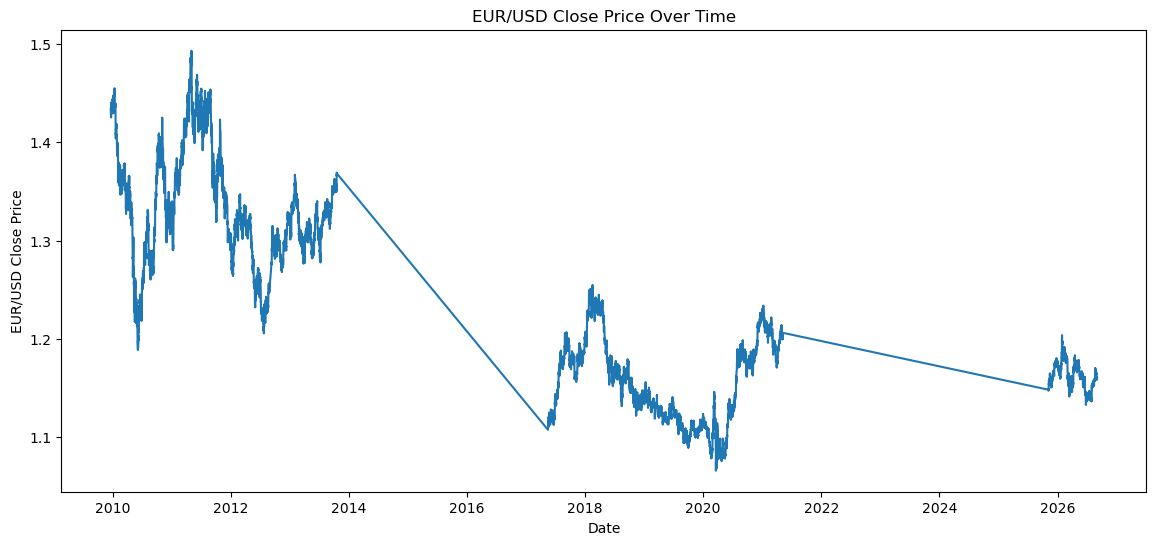

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    eurusd.index,
    eurusd["Close"]
)

plt.xlabel("Date")
plt.ylabel("EUR/USD Close Price")
plt.title("EUR/USD Close Price Over Time")

plt.show()

## 12. Plot a Smaller Time Window

When a dataset contains many years of observations, the full chart can be very dense.

We can display only the first 100 observations without changing the original dataset.


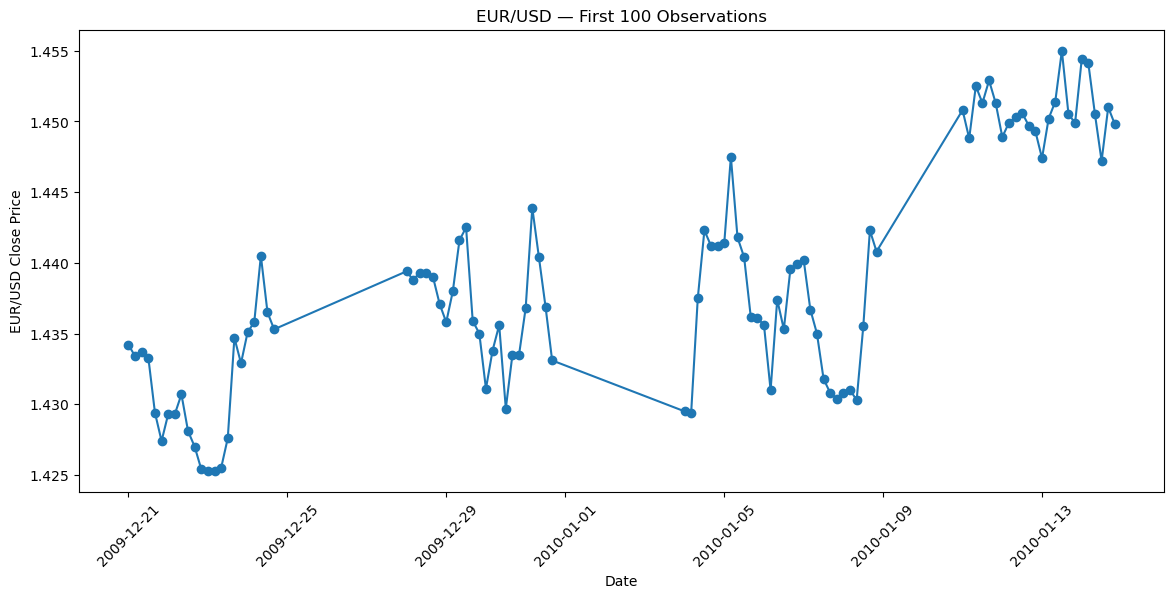

In [14]:
first_100 = eurusd.iloc[:100]

plt.figure(figsize=(14, 6))

plt.plot(
    first_100.index,
    first_100["Close"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("EUR/USD Close Price")
plt.title("EUR/USD — First 100 Observations")

plt.xticks(rotation=45)
plt.show()

## 13. Why We Do Not Shuffle Time Series Data

In many ordinary machine-learning datasets, rows can sometimes be randomly shuffled.

For time series, we normally preserve chronological order because:

- past observations occur before future observations
- previous prices may contain information about later prices
- random shuffling destroys the natural sequence
- future values must not accidentally be used to predict the past

So this would be inappropriate for our time series:

```python
eurusd.sample(frac=1)
```

We will preserve:

**past → present → future**


# Lesson 1 Practice

Answer these questions before looking at the suggested answers.

### Q1

Is the EUR/USD dataset a time series?

**A.** Yes  
**B.** No

---

### Q2

What represents time in our final DataFrame?

**A.** `Volume`  
**B.** `Close`  
**C.** `DateTimeIndex`  
**D.** `Open`

---

### Q3

Which column represents the price at the end of each candle?

**A.** `Open`  
**B.** `High`  
**C.** `Low`  
**D.** `Close`

---

### Q4

Why should we sort the DataFrame by its datetime index?

---

### Q5

Why should we normally avoid randomly shuffling EUR/USD observations before time-series analysis?

---

### Q6

Look at the full EUR/USD chart. Describe what you notice in your own words.

Do not worry yet about identifying trend, seasonality, stationarity, or forecasting. Those concepts belong to later lessons.


## Suggested Answers

**Q1:** A — Yes.

EUR/USD observations are recorded at specific points in time.

**Q2:** C — `DateTimeIndex`.

**Q3:** D — `Close`.

**Q4:** We sort the data so that observations follow their natural chronological order from oldest to newest.

**Q5:** Random shuffling destroys the time sequence and can mix past and future observations.

**Q6:** Your answer should describe only what you can visually observe, such as periods where the EUR/USD price rises, falls, or moves sideways. More formal analysis will come in later lessons.


# Final Practice Task

Using the `eurusd` DataFrame:

1. Display the first 5 observations.
2. Display the last 5 observations.
3. Print the earliest timestamp.
4. Print the latest timestamp.
5. Print the number of observations.
6. Display the first 20 values of `Close`.
7. Plot the first 200 `Close` observations.
8. Explain in one or two sentences why EUR/USD is a time series.

Write your code in the cell below.


In [16]:
# Write your final practice code here
#Display the first 5 observations.
eurusd.head(5)


,Open,High,Low,Close,Volume
DateTime,,,,,
2026-08-31 20:00:00,1.16160,1.16178,1.16137,1.16166,8555
2026-09-01 00:00:00,1.16157,1.16238,1.16121,1.16175,5772
2026-09-01 04:00:00,1.16177,1.16182,1.16022,1.16053,9671
2026-09-01 08:00:00,1.16052,1.16094,1.15874,1.15935,15737
2026-09-01 12:00:00,1.15935,1.16007,1.15893,1.15924,8914


In [20]:
#Display the last 5 observations
eurusd.tail(5)

,Open,High,Low,Close,Volume
DateTime,,,,,
2026-08-31 20:00:00,1.16160,1.16178,1.16137,1.16166,8555
2026-09-01 00:00:00,1.16157,1.16238,1.16121,1.16175,5772
2026-09-01 04:00:00,1.16177,1.16182,1.16022,1.16053,9671
2026-09-01 08:00:00,1.16052,1.16094,1.15874,1.15935,15737
2026-09-01 12:00:00,1.15935,1.16007,1.15893,1.15924,8914


In [25]:
#Print the earliest timestamp
eurusd.index.min()
#Print the number of observations.
print(len(eurusd))

13351


In [26]:
eurusd['Close'].head(20)

DateTime
2009-12-21 00:00:00    1.4342
2009-12-21 04:00:00    1.4334
2009-12-21 08:00:00    1.4337
2009-12-21 12:00:00    1.4333
2009-12-21 16:00:00    1.4294
2009-12-21 20:00:00    1.4274
2009-12-22 00:00:00    1.4293
2009-12-22 04:00:00    1.4293
2009-12-22 08:00:00    1.4307
2009-12-22 12:00:00    1.4281
2009-12-22 16:00:00    1.4270
2009-12-22 20:00:00    1.4254
2009-12-23 00:00:00    1.4253
2009-12-23 04:00:00    1.4253
2009-12-23 08:00:00    1.4255
2009-12-23 12:00:00    1.4276
2009-12-23 16:00:00    1.4347
2009-12-23 20:00:00    1.4329
2009-12-24 00:00:00    1.4351
2009-12-24 04:00:00    1.4358
Name: Close, dtype: float64

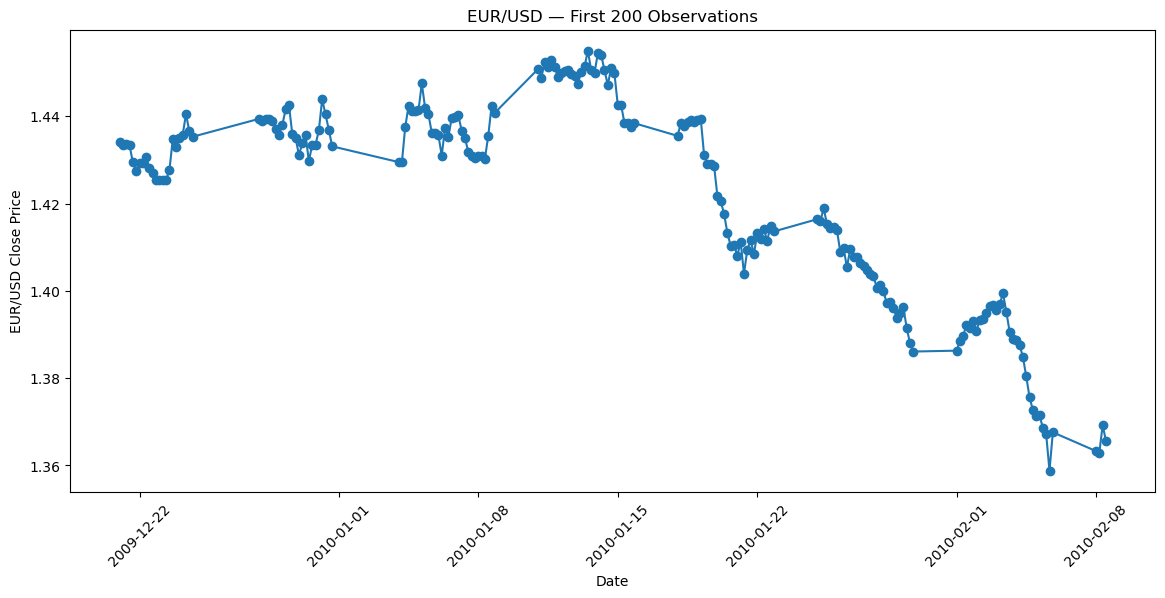

In [27]:
first_200 = eurusd.iloc[:200]

plt.figure(figsize=(14, 6))

plt.plot(
    first_200.index,
    first_200["Close"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("EUR/USD Close Price")
plt.title("EUR/USD — First 200 Observations")

plt.xticks(rotation=45)
plt.show()

# Lesson 1 Summary

From the EUR/USD project, you have now applied the main ideas from **Lesson 1 — What Is a Time Series?**

You learned that:

- EUR/USD data is indexed by time.
- Each timestamp contains Forex market observations.
- Date and time can be combined into a `DateTimeIndex`.
- Time series should be sorted chronologically.
- The sequence of observations matters.
- The `Close` price can be viewed as a simple time series.
- A line chart helps us see how a variable changes over time.
- Time series data should not normally be randomly shuffled.

We intentionally did **not** perform resampling, rolling statistics, returns, stationarity tests, forecasting, or trading signals because those belong to later lessons in the roadmap.
